# CDGAN on MNIST

In [1]:
# 기본 패키지 임포트
import os, random
from pathlib import Path


# torch 패키지 임포트
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# 데이터 처리 패키지 임포트
from torchvision import datasets, transforms, utils

# 시각화 패키지 임포트
import matplotlib.pyplot as plt

# Hyperparameter 설정

In [2]:
CFG = {
    "epochs": 10,
    "batch_size": 128,
    "lr": 2e-4,
    "beta1": 0.5,        # DCGAN 권장
    "beta2": 0.999,      # beta2=0.999
    "nz": 100,           # 잠재공간 차원
    "ngf": 64,           # G 채널 폭
    "ndf": 64,           # D 채널 폭
    "image_size": 64,
    "num_workers": 2,    # Colab이면 2 정도 권장
    "seed": 42,
    "out_dir": "/content/samples",
    "data_root": "/content/data",
    "num_classes": 10,   # MNIST 클래스 수(0~9)
    "user_digit" : 1
}

# 랜덤 시드 설정
random.seed(CFG["seed"])
torch.manual_seed(CFG["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 결과 저장 경로 생성
Path(CFG["out_dir"]).mkdir(parents=True, exist_ok=True)
Path(CFG["data_root"]).mkdir(parents=True, exist_ok=True)

# 데이터셋: MNIST 로드 및 전처리

In [3]:
# 데이터 전처리 정의
transform = transforms.Compose([
    transforms.Resize(CFG["image_size"]),
    transforms.ToTensor(),
    # AutoEncoder는 [0,1] 범위 사용
])

dataset = datasets.MNIST(
    root=CFG["data_root"], train=True, download=True, transform=transform
)

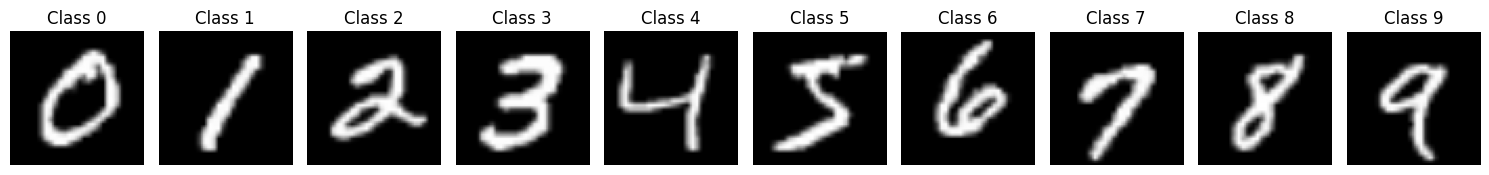

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# MNIST 각 클래스별로 첫 번째 이미지를 모아 시각화
class_images = [None] * CFG["num_classes"]
class_found = [False] * CFG["num_classes"]

for img, label in dataset:
    if not class_found[label]:
        class_images[label] = img
        class_found[label] = True
    if all(class_found):
        break

plt.figure(figsize=(15, 2))
for i in range(CFG["num_classes"]):
    plt.subplot(1, CFG["num_classes"], i + 1)
    plt.imshow(np.array(class_images[i]).squeeze(), cmap='gray')
    plt.title(f"Class {i}")
    plt.axis('off')
plt.tight_layout()
plt.show()


![Alt text](image.png)

In [5]:
# 데이터 전처리 정의
transform = transforms.Compose([
    transforms.Resize(CFG["image_size"]),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),  # [-1,1] 범위로 정규화
])

# 데이터 로더 생성
dloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=CFG["batch_size"],
    shuffle=True,
    num_workers=CFG["num_workers"],
    drop_last=True
)

# 모델 정의 (Conditional DCGAN)

In [6]:
nc = 1  # MNIST: 1채널
n_classes = CFG["num_classes"]

# 생성자 모델 정의
class Generator(nn.Module):
    def __init__(self, nz, ngf, nc, n_classes):
        super().__init__()
        in_ch = nz + n_classes  # z + one-hot(label)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(in_ch, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh(),  # 출력 [-1,1]
        )

    def forward(self, z, y_onehot):
        # z: (B,nz,1,1), y_onehot: (B,nC)
        y_ = y_onehot.unsqueeze(-1).unsqueeze(-1)   # (B,nC,1,1)
        zc = torch.cat([z, y_], dim=1)             # (B,nz+nC,1,1)
        return self.net(zc)

In [7]:
# 판별자 모델 정의
class Discriminator(nn.Module):
    def __init__(self, ndf, nc, n_classes):
        super().__init__()
        in_ch = nc + n_classes  # image + one-hot map
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x, y_onehot):
        # x: (B,1,64,64), y_onehot: (B,nC)
        B, _, H, W = x.shape
        y_map = y_onehot.unsqueeze(-1).unsqueeze(-1).expand(B, y_onehot.size(1), H, W)  # (B,nC,H,W)
        xc = torch.cat([x, y_map], dim=1)  # (B,1+nC,H,W)
        return self.net(xc).view(-1)

In [8]:
# 가중치 초기화 함수
def weights_init(m):
    cname = m.__class__.__name__
    if "Conv" in cname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in cname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

G = Generator(CFG["nz"], CFG["ngf"], nc, n_classes).to(device)
D = Discriminator(CFG["ndf"], nc, n_classes).to(device)
G.apply(weights_init)
D.apply(weights_init)

Discriminator(
  (net): Sequential(
    (0): Conv2d(11, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (12): Sigmoid()
  )
)

# 최적화 정의

In [9]:
criterion = nn.BCELoss()
optimD = optim.Adam(D.parameters(), lr=CFG["lr"], betas=(CFG["beta1"], 0.999))
optimG = optim.Adam(G.parameters(), lr=CFG["lr"], betas=(CFG["beta1"], 0.999))

# 시각화 및 샘플링을 위한 유틸 함수 정의

In [21]:
# 텐서 이미지 시각화 함수
def show_tensor_images(tensor, nrow=8, title="Generated"):
    grid = utils.make_grid(tensor, nrow=nrow, normalize=True, value_range=(-1, 1))
    plt.figure(figsize=(2,2))
    plt.axis('off')
    plt.title(title)
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
    plt.show()

# 고정된 그리드 샘플링 함수
@torch.no_grad() # 그래디언트 계산 비활성화
def sample_fixed_grid():
    # 0~9 라벨을 3회 반복(30)
    labels = torch.tensor(list(range(10)) * 3, device=device)
    y_oh = F.one_hot(labels, num_classes=n_classes).float()
    z = torch.randn(30, CFG["nz"], 1, 1, device=device)
    samples = G(z, y_oh).detach().cpu()
    return samples

# 특정 숫자 생성 함수
@torch.no_grad()
def generate_digit(digit=CFG["user_digit"], num=64):
    # 원하는 숫자(digit)를 num개 생성
    digit = int(digit); num = int(num)
    labels = torch.full((num,), digit, device=device, dtype=torch.long)
    y_oh = F.one_hot(labels, num_classes=n_classes).float()
    z = torch.randn(num, CFG["nz"], 1, 1, device=device)
    imgs = G(z, y_oh).detach().cpu()
    return imgs

# 모델 학습 (약 )

[1/10] step 0 | lossD=2.154 lossG=1.398
[1/10] step 100 | lossD=0.866 lossG=2.669
[1/10] step 200 | lossD=0.819 lossG=1.352
[1/10] step 300 | lossD=0.571 lossG=1.744
[1/10] step 400 | lossD=0.838 lossG=3.496
Saved: /content/samples/epoch_001.png


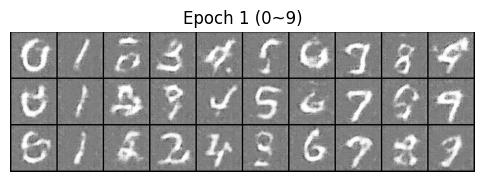

[2/10] step 500 | lossD=0.718 lossG=1.103
[2/10] step 600 | lossD=0.809 lossG=2.791
[2/10] step 700 | lossD=0.722 lossG=3.220
[2/10] step 800 | lossD=1.017 lossG=1.983
[2/10] step 900 | lossD=1.040 lossG=2.881
Saved: /content/samples/epoch_002.png


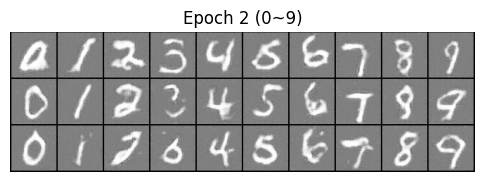

[3/10] step 1000 | lossD=1.150 lossG=0.767
[3/10] step 1100 | lossD=0.978 lossG=1.808
[3/10] step 1200 | lossD=1.018 lossG=1.663
[3/10] step 1300 | lossD=0.956 lossG=2.503
[3/10] step 1400 | lossD=0.732 lossG=1.625
Saved: /content/samples/epoch_003.png


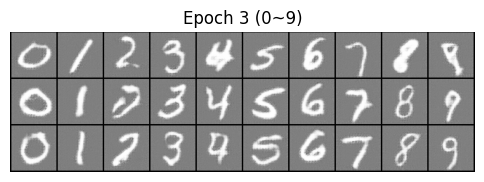

[4/10] step 1500 | lossD=0.747 lossG=3.364
[4/10] step 1600 | lossD=1.323 lossG=0.720
[4/10] step 1700 | lossD=0.824 lossG=2.060
[4/10] step 1800 | lossD=0.905 lossG=2.823
Saved: /content/samples/epoch_004.png


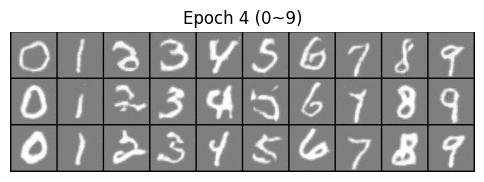

[5/10] step 1900 | lossD=0.576 lossG=2.099
[5/10] step 2000 | lossD=1.398 lossG=4.239
[5/10] step 2100 | lossD=0.851 lossG=2.578
[5/10] step 2200 | lossD=0.420 lossG=3.490
[5/10] step 2300 | lossD=0.284 lossG=2.992
Saved: /content/samples/epoch_005.png


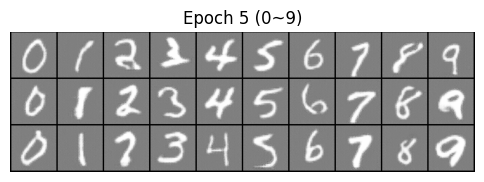

[6/10] step 2400 | lossD=0.486 lossG=2.422
[6/10] step 2500 | lossD=0.200 lossG=2.803
[6/10] step 2600 | lossD=0.482 lossG=4.646
[6/10] step 2700 | lossD=0.113 lossG=3.834
[6/10] step 2800 | lossD=0.639 lossG=3.058
Saved: /content/samples/epoch_006.png


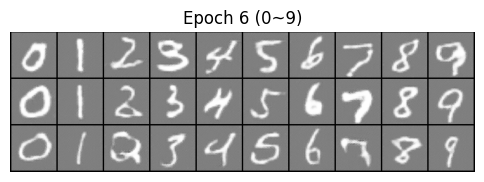

[7/10] step 2900 | lossD=0.519 lossG=4.374
[7/10] step 3000 | lossD=0.075 lossG=4.150
[7/10] step 3100 | lossD=0.939 lossG=1.599
[7/10] step 3200 | lossD=0.074 lossG=4.332
Saved: /content/samples/epoch_007.png


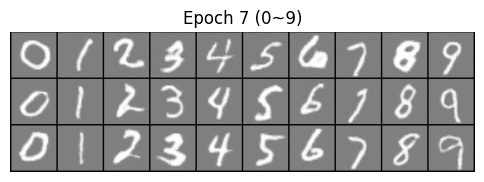

[8/10] step 3300 | lossD=0.554 lossG=3.167
[8/10] step 3400 | lossD=0.079 lossG=3.599
[8/10] step 3500 | lossD=0.037 lossG=4.765
[8/10] step 3600 | lossD=0.035 lossG=4.897
[8/10] step 3700 | lossD=0.698 lossG=2.818
Saved: /content/samples/epoch_008.png


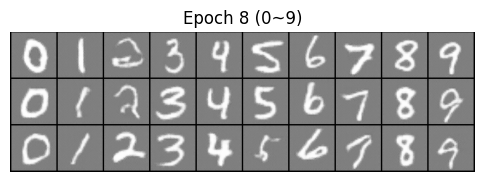

[9/10] step 3800 | lossD=0.157 lossG=4.964
[9/10] step 3900 | lossD=0.486 lossG=5.589
[9/10] step 4000 | lossD=0.103 lossG=4.041
[9/10] step 4100 | lossD=0.076 lossG=4.284
[9/10] step 4200 | lossD=0.019 lossG=5.726
Saved: /content/samples/epoch_009.png


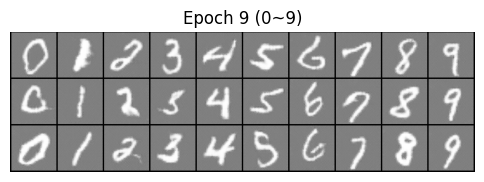

[10/10] step 4300 | lossD=0.013 lossG=6.935
[10/10] step 4400 | lossD=0.024 lossG=4.754
[10/10] step 4500 | lossD=0.025 lossG=5.369
[10/10] step 4600 | lossD=0.019 lossG=6.220
Saved: /content/samples/epoch_010.png


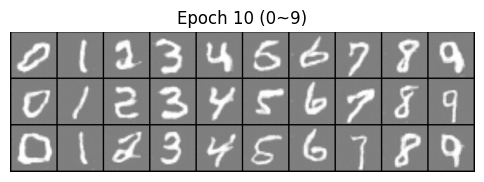

Training done. 샘플 이미지는 /content/samples 폴더에서 확인.


In [12]:
# 학습 시작
global_step = 0

# 학습 루프
for epoch in range(1, CFG["epochs"] + 1):
    for real, y in dloader:
        real = real.to(device)
        y = y.to(device)
        bsz = real.size(0)

        # one-hot labels
        y_onehot = F.one_hot(y, num_classes=n_classes).float()

        # --- (a) D 업데이트 ---
        D.zero_grad()
        label_real = torch.ones(bsz, device=device)
        label_fake = torch.zeros(bsz, device=device)

        # 진짜 이미지 판별
        out_real = D(real, y_onehot)
        loss_real = criterion(out_real, label_real)

        # 가짜 이미지 판별
        z = torch.randn(bsz, CFG["nz"], 1, 1, device=device)
        fake = G(z, y_onehot)
        out_fake = D(fake.detach(), y_onehot)
        loss_fake = criterion(out_fake, label_fake)

        lossD = loss_real + loss_fake
        lossD.backward()
        optimD.step()

        # --- (b) G 업데이트 ---
        G.zero_grad()
        out_fake_forG = D(fake, y_onehot)
        lossG = criterion(out_fake_forG, label_real)  # 가짜를 1로 속이기
        lossG.backward()
        optimG.step()

        # 학습 진행 상황 출력
        if global_step % 100 == 0:
            print(f"[{epoch}/{CFG['epochs']}] step {global_step} | "
                  f"lossD={lossD.item():.3f} lossG={lossG.item():.3f}")
        global_step += 1

    # Epoch마다 샘플 저장 & 표시 (0~9 고정 그리드)
    with torch.no_grad():
        samples = sample_fixed_grid()
    save_path = os.path.join(CFG["out_dir"], f"epoch_{epoch:03d}.png")
    utils.save_image(samples, save_path, nrow=10, normalize=True, value_range=(-1, 1))
    print(f"Saved: {save_path}")
    show_tensor_images(samples, nrow=10, title=f"Epoch {epoch} (0~9)")

print("Training done. 샘플 이미지는 /content/samples 폴더에서 확인.")

# 원하는 숫자의 이미지 생성

Select Number (0-9):3


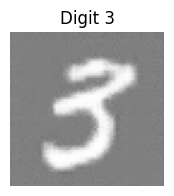

In [23]:
num = input("Select Number (0-9):")
show_tensor_images(generate_digit(f'{num}', num=1), nrow=1, title=f"Digit {num}")